In [3]:
import pandas as pd
df = pd.read_csv("sales.csv")
df.head()

d:\Anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\Anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# Step2: Exploratory Data Analysis（EDA）
display(df.info())        
display(df.describe() )   
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

None

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

We found 11 missing entries in the postal code.

In [5]:
# Adjust the date format
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [6]:
# Aggregate sales by date
daily_sales = df.groupby("Order Date")["Sales"].sum()
daily_sales.head()

Order Date
2015-01-03      16.448
2015-01-04     288.060
2015-01-05      19.536
2015-01-06    4407.100
2015-01-07      87.158
Name: Sales, dtype: float64

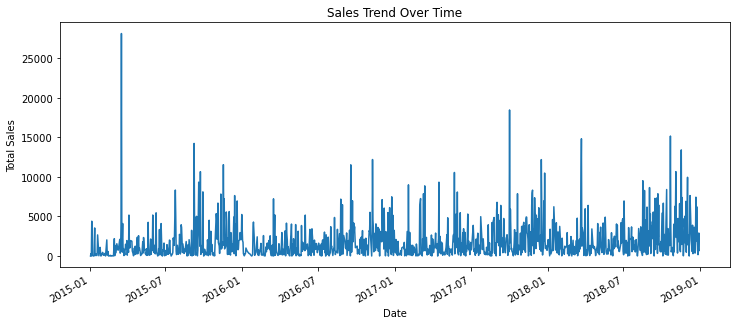

In [7]:
# Daily Sales Trend Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

daily_sales.plot()

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

Sales show an overall increasing trend from 2015 to 2018, indicating business growth over time.
Daily sales exhibit high volatility, suggesting fluctuating order volumes and possible seasonal demand patterns.
Several extreme spikes indicate the presence of large transactions or promotional events.

In [8]:
# Regional Sales Comparison Analysis
region_sales = df.groupby("Region")["Sales"].sum()
region_sales

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

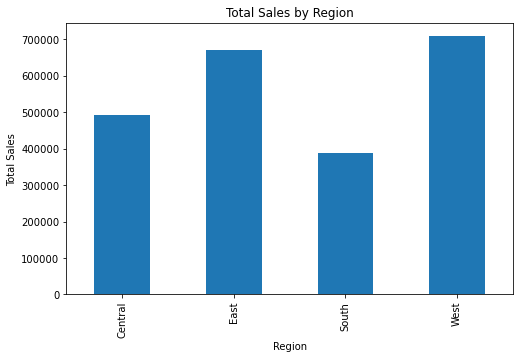

In [9]:
# Bar Chart of Sales By Region
region_sales.plot(kind="bar", figsize=(8,5))
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

The West region generates the highest total sales, indicating it is the company’s primary revenue driver.
The East region also shows strong performance, suggesting stable market demand.
The South region has significantly lower sales, indicating potential opportunities for market expansion.

In [10]:
# Calculate the percentage contribution of total sales for each region
region_sales_percent = region_sales / region_sales.sum() * 100
region_sales_percent

Region
Central    21.783723
East       29.604591
South      17.207390
West       31.404295
Name: Sales, dtype: float64

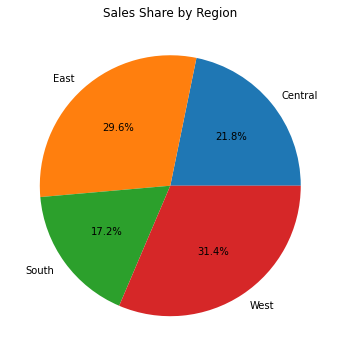

In [11]:
# Pie Chart of Sales By Region
region_sales_percent.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Sales Share by Region")
plt.ylabel("") 
plt.show()

The West and East regions dominate total sales, suggesting strong market demand and customer base in these areas. In contrast, the South region represents a relatively small share, indicating potential opportunities for market expansion and targeted marketing efforts.

In [12]:
# Product Performance Analysis
category_sales = df.groupby("Category")["Sales"].sum()
category_sales

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

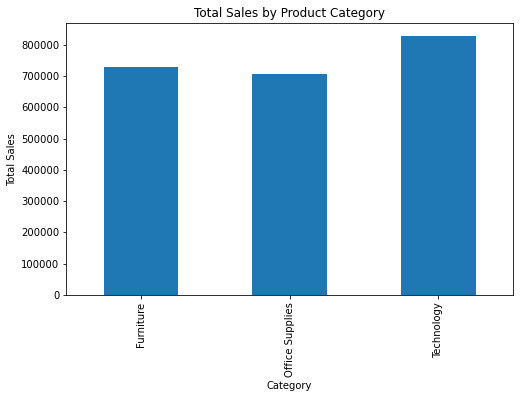

In [13]:
# Bar Chart of Sales By Category
category_sales.plot(kind="bar", figsize=(8,5))
plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

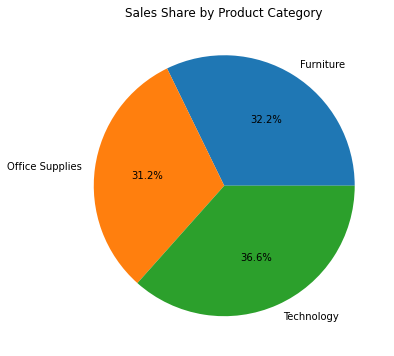

In [14]:
# Calculate the percentage contribution of total sales for each category
category_percent = category_sales / category_sales.sum() * 100
category_percent.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Sales Share by Product Category")
plt.ylabel("")
plt.show()

Technology products represent the largest share of total sales, indicating strong market demand in this category. Meanwhile, sales are relatively evenly distributed across all product categories, suggesting a well-balanced product portfolio that supports revenue stability and reduces dependence on a single market segment.

In [15]:
# KPI（Key Performance Indicators）
total_sales = df["Sales"].sum()
avg_sales = df["Sales"].mean()
total_orders = len(df)

print("Total Sales:", round(total_sales, 2))
print("Average Order Value:", round(avg_sales, 2))
print("Total Orders:", total_orders)

Total Sales: 2261536.78
Average Order Value: 230.77
Total Orders: 9800


In [16]:
top_region = region_sales.idxmax()
top_category = category_sales.idxmax()

print("Top Region:", top_region)
print("Top Category:", top_category)

Top Region: West
Top Category: Technology


In [17]:
from IPython.display import display, Markdown

display(Markdown(f"""
## Sales Performance Dashboard Summary

**Total Sales:** ${total_sales:,.0f}  
**Average Order Value:** ${avg_sales:.2f}  
**Total Orders:** {total_orders:,}

###  Key Drivers
- **Top Region:** {top_region}
- **Top Product Category:** {top_category}
"""))


## Sales Performance Dashboard Summary

**Total Sales:** $2,261,537  
**Average Order Value:** $230.77  
**Total Orders:** 9,800

###  Key Drivers
- **Top Region:** West
- **Top Product Category:** Technology
